In [77]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [78]:
def load_data(filepath=r'C:\Users\Bhuwan\Desktop\dimentia\FINAL_DATASET_FOR_DEMENTIA_VAIBHAV_GUPTA (1).xlsx'):
    """Loads and cleans the dementia dataset safely."""

    import pandas as pd

    try:
        # -----------------------------
        # LOAD FILE (AUTO DETECT)
        # -----------------------------
        if filepath.endswith('.csv'):
            df = pd.read_csv(filepath)
        elif filepath.endswith('.xlsx'):
            df = pd.read_excel(filepath)
        else:
            raise ValueError("Unsupported file format")

        # -----------------------------
        # 🔥 CLEAN COLUMN NAMES (VERY IMPORTANT)
        # -----------------------------
        df.columns = (
            df.columns
            .str.strip()            # remove spaces
            .str.upper()            # make uppercase
            .str.replace(" ", "_")  # replace spaces with _
        )

        print(f"✅ Successfully loaded '{filepath}'")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {df.columns.tolist()}")

        # -----------------------------
        # 🎯 TARGET CHECK (FIXED)
        # -----------------------------
        if 'DEMENTIA' in df.columns:
            print("\n📊 Target distribution:")
            print(df['DEMENTIA'].value_counts().to_string())
        else:
            print("❌ ERROR: 'DEMENTIA' column not found!")
            print("👉 Available columns:", df.columns.tolist())
            return None

        return df

    except FileNotFoundError:
        print(f"❌ Error: '{filepath}' not found.")
        return None

    except Exception as e:
        print(f"❌ Error loading file: {e}")
        return None


In [79]:
def preprocess_data(df):
    """
    Prepares features and target.

    CDR is DROPPED because it is derived from the Dementia diagnosis itself —
    keeping it causes data leakage (CDR=0 always means no dementia, CDR>0
    always means demented). No scaling is applied since XGBoost is a
    tree-based model and does not require it.
    """

    # -------------------------------------------------------------------------
    # DROP CDR — critical fix for data leakage
    # CDR perfectly separates classes (correlation = 0.87 with target).
    # Including it would make the model trivially predict from the label itself.
    # -------------------------------------------------------------------------
    LEAKAGE_COLS = ['DEMENTIA', 'CDR']
    X = df.drop(columns=LEAKAGE_COLS)
    y = df['DEMENTIA']
    feature_names = X.columns.tolist()

    print(f"Features used ({len(feature_names)}): {feature_names}")
    print("⚠️  CDR intentionally excluded — it is derived from the diagnosis label.\n")

    # 80/20 stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
    print(f"Train class balance: {y_train.value_counts().to_dict()}")
    print(f"Test  class balance: {y_test.value_counts().to_dict()}\n")

    # NOTE: No StandardScaler — XGBoost is tree-based and invariant to scaling.
    return X_train, X_test, y_train, y_test, feature_names

In [80]:
def cv_baseline(X_train, y_train):
    """
    Reports 10-fold stratified CV scores with mean ± std
    to give a stable estimate of model performance before tuning.
    """
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    base_model = XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    )

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    for metric in ['recall', 'roc_auc', 'accuracy']:
        scores = cross_val_score(base_model, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
        print(f"  CV {metric:10s}: {scores.mean():.3f} ± {scores.std():.3f}")

    print()

In [81]:
def _plot_confusion_matrix(y_test, y_pred, threshold):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Nondemented', 'Demented'],
        yticklabels=['Nondemented', 'Demented']
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix (threshold={threshold:.2f})')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()
    print("📊 Saved: confusion_matrix.png")
def _plot_roc_curve(y_test, y_prob, auc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve — XGBoost (CDR excluded)')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150)
    plt.show()
    print("📊 Saved: roc_curve.png")


def _plot_feature_importance(model, feature_names):
    importance = model.feature_importances_
    feat_df = pd.DataFrame({
        'Feature':    feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(7, 4))
    plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
    plt.xlabel('Feature Importance (gain)')
    plt.title('XGBoost Feature Importance (CDR excluded)')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
    print("📊 Saved: feature_importance.png")

In [82]:
def train_and_evaluate(X_train, y_train, X_test, y_test, feature_names):
    """
    Final Stable Version:
    - Version-safe (no early stopping issues)
    - Clean separation of concerns
    - Robust threshold tuning
    """

    from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
    from sklearn.metrics import (
        accuracy_score, classification_report,
        roc_auc_score, precision_recall_curve
    )
    from xgboost import XGBClassifier
    import numpy as np

    # -----------------------------
    # CLASS IMBALANCE
    # -----------------------------
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # -----------------------------
    # PARAM SEARCH
    # -----------------------------
    param_dist = {
        'n_estimators':     [100, 200, 300],
        'max_depth':        [3, 4, 5, 6],
        'learning_rate':    [0.01, 0.05, 0.1],
        'subsample':        [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    }

    xgb = XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    )

    print("🚀 Running RandomizedSearch...")

    search = RandomizedSearchCV(
        xgb,
        param_distributions=param_dist,
        n_iter=20,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='recall',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    print(f"\n✅ Best params: {search.best_params_}")

    # -----------------------------
    # TRAIN FINAL MODEL (SAFE)
    # -----------------------------
    best_model.fit(X_train, y_train)

    # -----------------------------
    # PREDICTIONS
    # -----------------------------
    y_prob = best_model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    # -----------------------------
    # DEFAULT THRESHOLD
    # -----------------------------
    y_pred_default = (y_prob >= 0.5).astype(int)

    print("\n--- Default Threshold (0.5) ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred_default):.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(y_test, y_pred_default))

    # -----------------------------
    # 🔥 THRESHOLD SELECTION
    # -----------------------------
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

    best_threshold = 0.5
    best_score = -1

    for i in range(len(thresholds)):
        p = precision[i]
        r = recall[i]
        t = thresholds[i]

        f1 = (2 * p * r) / (p + r + 1e-6)

        # Priority: recall ≥ 0.90
        if r >= 0.90 and f1 > best_score:
            best_score = f1
            best_threshold = t

    # fallback
    if best_score == -1:
        print("⚠️ Using best F1 (no recall ≥ 0.90 found)")
        for i in range(len(thresholds)):
            p = precision[i]
            r = recall[i]
            t = thresholds[i]

            f1 = (2 * p * r) / (p + r + 1e-6)

            if f1 > best_score:
                best_score = f1
                best_threshold = t

    # -----------------------------
    # FINAL EVALUATION
    # -----------------------------
    y_pred_tuned = (y_prob >= best_threshold).astype(int)

    print(f"\n--- Tuned Threshold ({best_threshold:.3f}) ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(y_test, y_pred_tuned))

    # -----------------------------
    # PLOTS
    # -----------------------------
    _plot_confusion_matrix(y_test, y_pred_tuned, best_threshold)
    _plot_roc_curve(y_test, y_prob, auc)
    _plot_feature_importance(best_model, feature_names)

    return best_model, best_threshold



In [83]:
def save_artifacts(model, feature_names, threshold):
    """Saves model, feature names, and threshold."""

    import joblib

    joblib.dump(model, 'dementia_model.pkl')
    joblib.dump(feature_names, 'feature_names.pkl')
    joblib.dump(threshold, 'threshold.pkl')  # 🔥 ADD THIS

    print("\n✅ Artifacts saved:")
    print("   - dementia_model.pkl")
    print("   - feature_names.pkl")
    print("   - threshold.pkl")
    print("   (No scaler needed — XGBoost does not require scaling)")
    print("\n➡️  Ready for prediction (3_questionnaire.py)")


In [84]:
def main():
    # 1. Load
    df = load_data(filepath=r'C:\Users\Bhuwan\Desktop\dimentia\FINAL_DATASET_FOR_DEMENTIA_VAIBHAV_GUPTA (1).xlsx')
    if df is None:
        return

    # 2. Preprocess (CDR dropped)
    X_train, X_test, y_train, y_test, feature_names = preprocess_data(df)

    # 3. CV baseline — stable estimate before tuning
    print("--- 10-Fold Cross-Validation Baseline ---")
    cv_baseline(X_train, y_train)

    # 4. Tune + evaluate
    model, threshold = train_and_evaluate(X_train, y_train, X_test, y_test, feature_names)

    save_artifacts(model, feature_names, threshold)

    print("\n🎉 Pipeline complete!")



✅ Successfully loaded 'C:\Users\Bhuwan\Desktop\dimentia\FINAL_DATASET_FOR_DEMENTIA_VAIBHAV_GUPTA (1).xlsx'
   Shape: (92327, 8)
   Columns: ['AGE', 'GENDER', 'YEARS_OF_EDUCATION', 'SES', 'EDUCATION', 'MMSE', 'CDR', 'DEMENTIA']

📊 Target distribution:
DEMENTIA
0    68581
1    23746
Features used (6): ['AGE', 'GENDER', 'YEARS_OF_EDUCATION', 'SES', 'EDUCATION', 'MMSE']
⚠️  CDR intentionally excluded — it is derived from the diagnosis label.

Train size: 73861 | Test size: 18466
Train class balance: {0: 54864, 1: 18997}
Test  class balance: {0: 13717, 1: 4749}

--- 10-Fold Cross-Validation Baseline ---
  CV recall    : 0.825 ± 0.008
  CV roc_auc   : 0.926 ± 0.004
  CV accuracy  : 0.860 ± 0.002

🚀 Running RandomizedSearch...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

--- Default Threshold (0.5) ---
Accuracy : 0.8591
ROC-AUC  : 0.9248
              preci

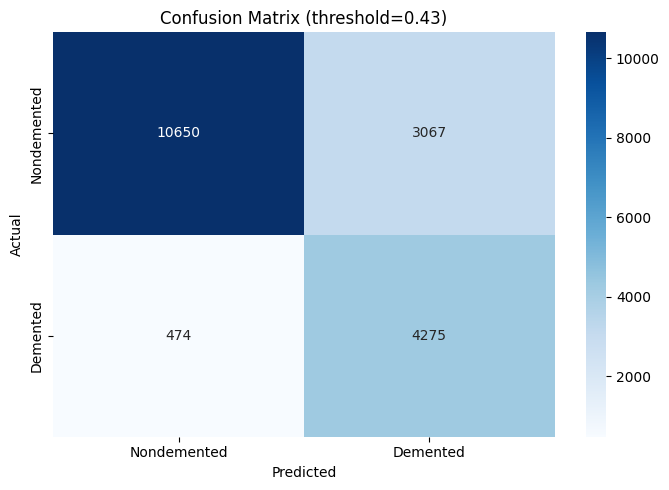

📊 Saved: confusion_matrix.png


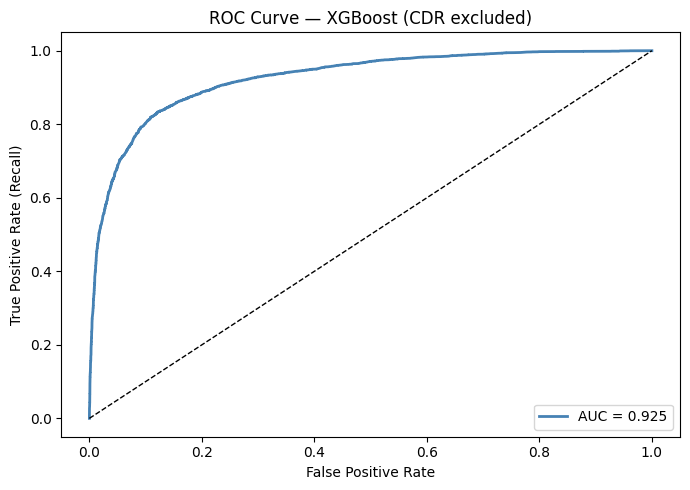

📊 Saved: roc_curve.png


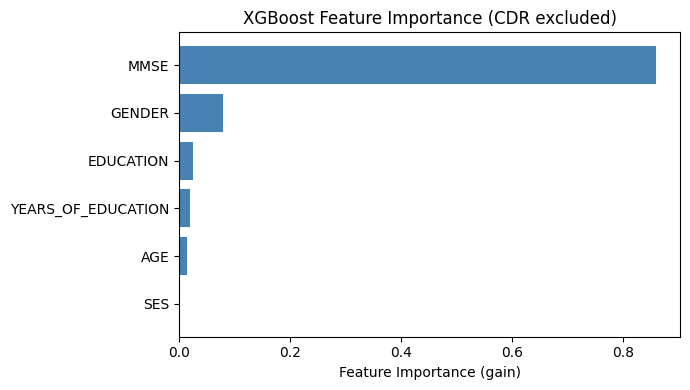

📊 Saved: feature_importance.png

✅ Artifacts saved:
   - dementia_model.pkl
   - feature_names.pkl
   - threshold.pkl
   (No scaler needed — XGBoost does not require scaling)

➡️  Ready for prediction (3_questionnaire.py)

🎉 Pipeline complete!


In [85]:
if __name__ == '__main__':
    main()